# Mean/Median Imputation


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('titanic_toy.csv')

In [ ]:
df.shape

(891, 4)

In [ ]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [ ]:
df.isnull().mean()*100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [ ]:
X_train.isnull().mean()

,0
Age,0.196629
Fare,0.050562
Family,0.000000


In [ ]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [ ]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [ ]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
871,47.0,NaN,2,47.000000,47.0,32.517788,14.4000
249,54.0,26.0000,1,54.000000,54.0,26.000000,26.0000
547,NaN,13.8625,0,29.498846,28.0,13.862500,13.8625
660,50.0,133.6500,2,50.000000,50.0,133.650000,133.6500
365,30.0,7.2500,0,30.000000,30.0,7.250000,7.2500


In [ ]:
print(f"Variance of Age: {X_train['Age'].var()}")
print(f"Variance of Age_mean: {X_train['Age_mean'].var()}")
print(f"Variance of Age_median: {X_train['Age_median'].var()}")
print(f"Variance of Fare: {X_train['Fare'].var()}")
print(f"Variance of Fare_mean: {X_train['Fare_mean'].var()}")
print(f"Variance of Fare_median: {X_train['Fare_median'].var()}")

Variance of Age: 210.2517072477438
Variance of Age_mean: 168.8519336687225
Variance of Age_median: 169.20731007048096
Variance of Fare: 2761.031434948639
Variance of Fare_mean: 2621.2323749512393
Variance of Fare_median: 2637.01248167777


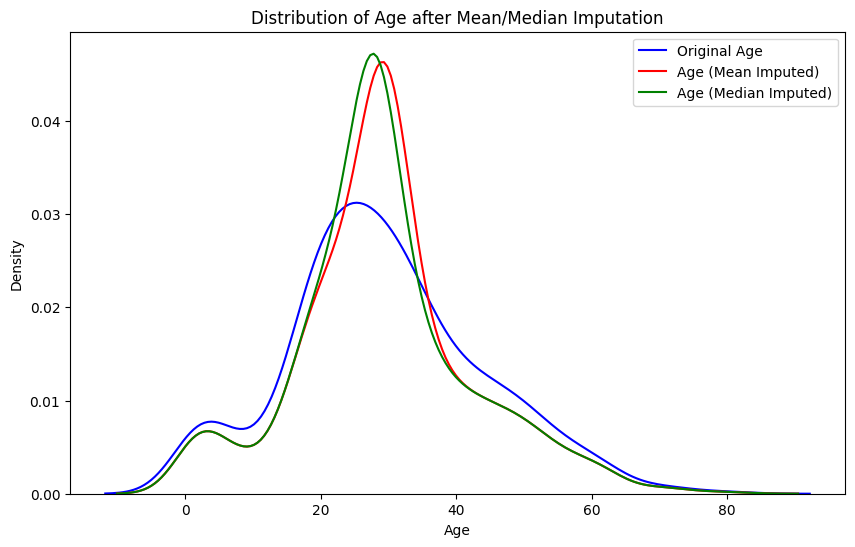

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(X_train['Age'], label='Original Age', color='blue')
sns.kdeplot(X_train['Age_mean'], label='Age (Mean Imputed)', color='red')
sns.kdeplot(X_train['Age_median'], label='Age (Median Imputed)', color='green')
plt.title('Distribution of Age after Mean/Median Imputation')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

# Red Flag

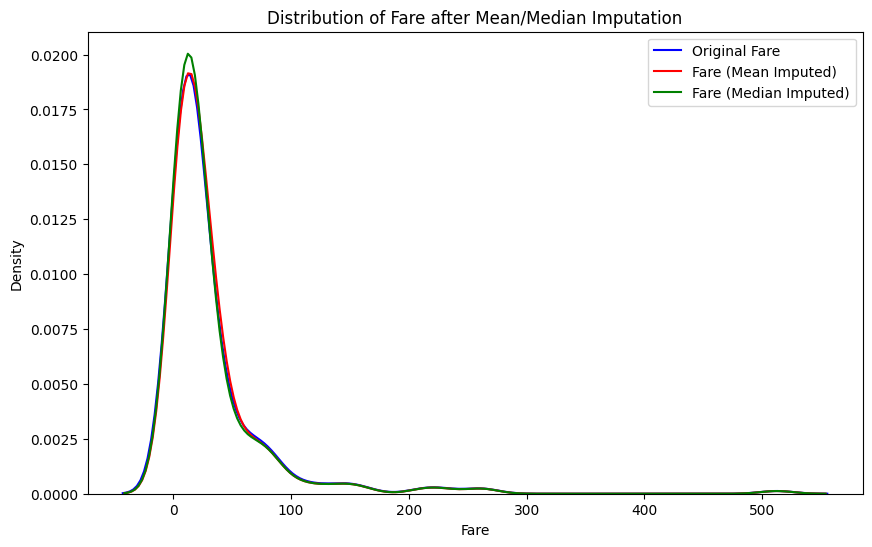

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(X_train['Fare'], label='Original Fare', color='blue')
sns.kdeplot(X_train['Fare_mean'], label='Fare (Mean Imputed)', color='red')
sns.kdeplot(X_train['Fare_median'], label='Fare (Median Imputed)', color='green')
plt.title('Distribution of Fare after Mean/Median Imputation')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend()
plt.show()

# Green Flag

In [ ]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [ ]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

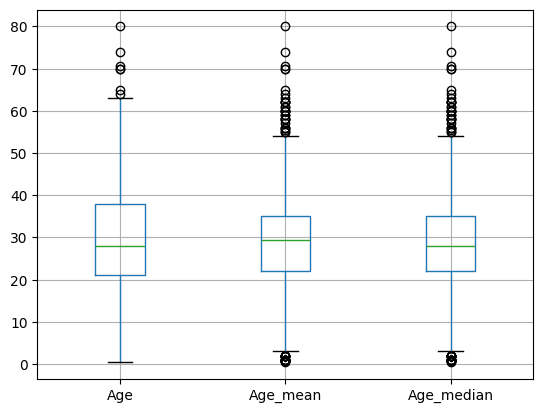

In [ ]:
X_train[['Age', 'Age_mean', 'Age_median']].boxplot()

<Axes: >

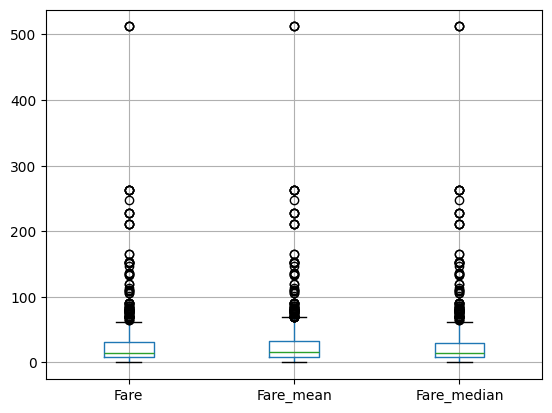

In [ ]:
X_train[['Fare', 'Fare_mean', 'Fare_median']].boxplot()

# Mean/Median Imputation (Sklearn)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [ ]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [ ]:
trf = ColumnTransformer([
    ('mean_imputer', imputer1, ['Age']),
    ('median_imputer', imputer2, ['Fare'])
], remainder='passthrough')

In [ ]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('mean_imputer', SimpleImputer(), ['Age']),
                                ('median_imputer',
                                 SimpleImputer(strategy='median'), ['Fare'])])

In [ ]:
trf.named_transformers_['mean_imputer'].statistics_

array([29.49884615])

In [ ]:
trf.named_transformers_['median_imputer'].statistics_

array([14.4])

In [ ]:
X_train_transformed = trf.transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
X_train_transformed

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])

# Arbitrary Value imputation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_toy.csv')

In [3]:
df.sample(5)

,Age,Fare,Family,Survived
233,5.0,31.3875,6,1
31,NaN,146.5208,1,1
258,35.0,512.3292,0,1
756,28.0,7.7958,0,0
104,37.0,7.9250,2,0


In [9]:
df.describe()

,Age,Fare,Family,Survived
count,714.000000,846.000000,891.000000,891.000000
mean,29.699118,32.279338,0.904602,0.383838
std,14.526497,50.305796,1.613459,0.486592
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.206250,1.000000,1.000000
max,80.000000,512.329200,10.000000,1.000000


In [4]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [5]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train['Age_arbitrary'] = X_train['Age'].fillna(99)
X_train['Fare_arbitrary'] = X_train['Fare'].fillna(999)

X_train['Age_arbitraryminu1'] = X_train['Age'].fillna(-1)
X_train['Fare_arbitraryminu1'] = X_train['Fare'].fillna(-1)

In [7]:
X_train.sample(5)

,Age,Fare,Family,Age_arbitrary,Fare_arbitrary,Age_arbitraryminu1,Fare_arbitraryminu1
540,36.0,71.00,2,36.0,71.00,36.0,71.00
263,40.0,0.00,0,40.0,0.00,40.0,0.00
262,52.0,79.65,2,52.0,79.65,52.0,79.65
406,51.0,7.75,0,51.0,7.75,51.0,7.75
434,50.0,NaN,1,50.0,999.00,50.0,-1.00


In [8]:
print(f"Variance of Age: {X_train['Age'].var()}")
print(f"Variance of Age_arbitrary: {X_train['Age_arbitrary'].var()}")
print(f"Variance of Age_arbitraryminu1: {X_train['Age_arbitraryminu1'].var()}")
print(f"Variance of Fare: {X_train['Fare'].var()}")
print(f"Variance of Fare_arbitrary: {X_train['Fare_arbitrary'].var()}")
print(f"Variance of Fare_arbitraryminu1: {X_train['Fare_arbitraryminu1'].var()}")

Variance of Age: 210.2517072477438
Variance of Age_arbitrary: 932.9665366701436
Variance of Age_arbitraryminu1: 315.99550362600644
Variance of Fare: 2761.031434948639
Variance of Fare_arbitrary: 47525.47059536007
Variance of Fare_arbitraryminu1: 2675.2394049177087


<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>

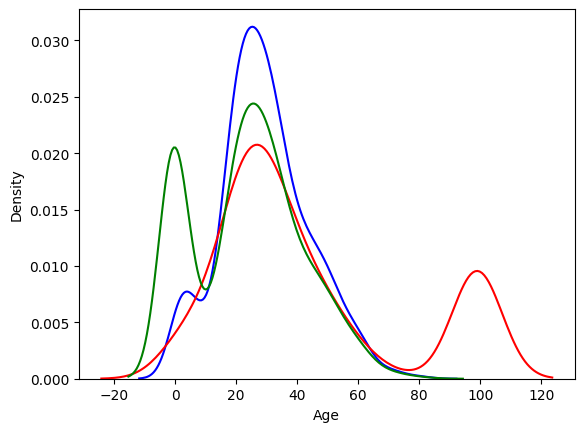

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

sns.kdeplot(X_train['Age'], label='Original Age', color='blue', ax=ax)
sns.kdeplot(X_train['Age_arbitrary'], label='Age (Arbitrary Imputed 99)', color='red', ax=ax)
sns.kdeplot(X_train['Age_arbitraryminu1'], label='Age (Arbitrary Imputed -1)', color='green', ax=ax)
sns

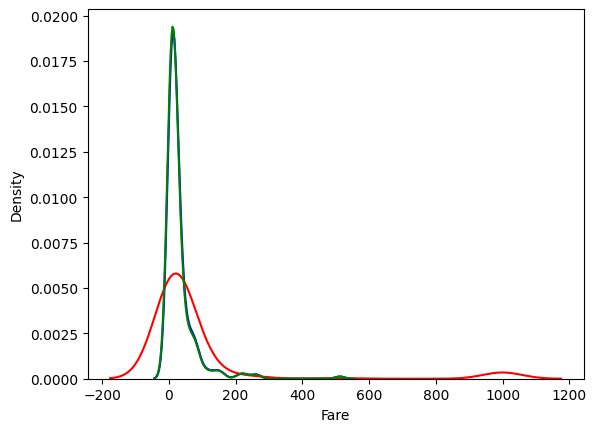

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

sns.kdeplot(X_train['Fare'], label='Original Fare', color='blue', ax=ax)
sns.kdeplot(X_train['Fare_arbitrary'], label='Fare (Arbitrary Imputed 999)', color='red', ax=ax)
sns.kdeplot(X_train['Fare_arbitraryminu1'], label='Fare (Arbitrary Imputed -1)', color='green', ax=ax)
plt.show()

In [15]:
X_train.cov()

,Age,Fare,Family,Age_arbitrary,Fare_arbitrary,Age_arbitraryminu1,Fare_arbitraryminu1
Age,210.251707,75.481375,-6.993325,210.251707,130.495777,210.251707,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,2761.031435,135.785804,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,16.878492,-5.034556,17.684447
Age_arbitrary,210.251707,-111.965046,-6.941982,932.966537,-255.051165,-166.460682,-101.137070
Fare_arbitrary,130.495777,2761.031435,16.878492,-255.051165,47525.470595,262.712284,1063.944817
Age_arbitraryminu1,210.251707,135.785804,-5.034556,-166.460682,262.712284,315.995504,124.270305
Fare_arbitraryminu1,69.137162,2761.031435,17.684447,-101.137070,1063.944817,124.270305,2675.239405


# Arbitrary Value imputation (Sklearn)

In [16]:
from sklearn.impute import SimpleImputer

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=-1)

In [20]:
from sklearn.compose import ColumnTransformer
trf = ColumnTransformer([
    ('arbitrary_imputer1', imputer1, ['Age']),
    ('arbitrary_imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [21]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('arbitrary_imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('arbitrary_imputer2',
                                 SimpleImputer(fill_value=-1,
                                               strategy='constant'),
                                 ['Fare'])])

In [22]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [23]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  -1.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])

# End of Distribution Imputation